TAHAP 1 - AMBIL VIDEO DARI YOUTUBE YANG SESUAI DENGAN KEYWORDS

In [18]:
from yt_dlp import YoutubeDL
import pandas as pd

print("OK")

OK


1.1 Tentukan Keywords yang Sesuai Dengan Tema Yang Ingin Dibahas

In [19]:
keywords = [
    "rupiah melemah",
    "rupiah anjlok",
    "kurs rupiah",
    "nilai tukar rupiah",
    "dollar naik",
    "usd idr",
    "rupiah terhadap dolar",
    "bank indonesia",
    "bi rate",
    "inflasi indonesia",
    "deflasi indonesia",
    "ekonomi indonesia",
    "apbn indonesia",
    "makan bergizi gratis",
    "MBG",
    "cadangan devisa",
    "ekspor indonesia",
    "impor indonesia",
    "investasi indonesia",
    "IHSG",
]

def search_videos(keyword, max_results=20):

    ydl_opts = {
        "quiet": True,
        "extract_flat": True,
        "skip_download": True
    }

    with YoutubeDL(ydl_opts) as ydl:

        search_result = ydl.extract_info(
            f"ytsearch{max_results}:{keyword}",
            download=False
        )

    return search_result["entries"]


1.2 Berikan Tambahan Kata yang Kurang Sesuai agar Dapat Menyingkirkan Video yang dianggap sebagai Noise

In [20]:
banned_words = [
    "shorts",
    "live",
    "livestream",
    "streaming",
    "trading",
    "forex",
    "signal",
    "prediksi",
    "robot",
    "crypto",
    "bitcoin",
    "giveaway",
    "DJ",
    "Tiktok",
    "Ganteng",
    "dj",
    "ganteng",
    "lagu"
]

In [21]:
def is_valid_video(title):

    title = title.lower()

    for word in banned_words:

        if word in title:
            return False

    return True

In [22]:
all_videos = []

for keyword in keywords:

    print(f"Mencari video: {keyword}")

    try:

        videos = search_videos(
            keyword,
            max_results=30
        )

        for video in videos:

            title = video.get("title", "")
            if not is_valid_video(title):
                continue

            all_videos.append({
                "keyword": keyword,
                "video_id": video.get("id"),
                "title": video.get("title"),
                "channel": video.get("channel"),
                "url": f"https://www.youtube.com/watch?v={video.get('id')}"
            })

    except Exception as e:

        print(f"Error pada keyword {keyword}: {e}")

Mencari video: rupiah melemah
Mencari video: rupiah anjlok
Mencari video: kurs rupiah
Mencari video: nilai tukar rupiah
Mencari video: dollar naik
Mencari video: usd idr
Mencari video: rupiah terhadap dolar
Mencari video: bank indonesia
Mencari video: bi rate
Mencari video: inflasi indonesia
Mencari video: deflasi indonesia


Mencari video: ekonomi indonesia
Mencari video: apbn indonesia
Mencari video: makan bergizi gratis
Mencari video: MBG
Mencari video: cadangan devisa
Mencari video: ekspor indonesia
Mencari video: impor indonesia
Mencari video: investasi indonesia
Mencari video: IHSG


In [23]:
df = pd.DataFrame(all_videos)

print("Jumlah video sebelum deduplikasi:")
print(len(df))

Jumlah video sebelum deduplikasi:
560


In [24]:
df = df.drop_duplicates(
    subset=["video_id"]
)

print("Jumlah video setelah deduplikasi:")
print(len(df))

Jumlah video setelah deduplikasi:
467


In [25]:
df.to_csv(
    "youtube_videos.csv",
    index=False,
    encoding="utf-8-sig"
)

In [26]:
print(df.head())

          keyword     video_id  \
0  rupiah melemah  ZY4UiIBBDz4   
1  rupiah melemah  BuwlIc1NKXk   
2  rupiah melemah  K9TMbfCiev8   
3  rupiah melemah  Y1Y74j5OTVs   
4  rupiah melemah  ln4DaJ1bXQs   

                                               title                 channel  \
0  IHSG Ambles dan Rupiah Melemah, Purbaya Sebut ...                KOMPASTV   
1  Rupiah Melemah, Pengusaha Tahu Tempe Terpaksa ...                Liputan6   
2  Rupiah Melemah ke Rp18.105 Per Dolar AS Sentim...               METRO TV    
3  Why Does the Rupiah Keep Weakening and Breakin...              Kompas.com   
4  Alasan Menkeu Purabaya Tak Panik Meski Rupiah ...  Tribun Kaltim Official   

                                           url  
0  https://www.youtube.com/watch?v=ZY4UiIBBDz4  
1  https://www.youtube.com/watch?v=BuwlIc1NKXk  
2  https://www.youtube.com/watch?v=K9TMbfCiev8  
3  https://www.youtube.com/watch?v=Y1Y74j5OTVs  
4  https://www.youtube.com/watch?v=ln4DaJ1bXQs  


In [27]:
print(df["keyword"].value_counts())

keyword
makan bergizi gratis     30
cadangan devisa          30
rupiah melemah           29
ekspor indonesia         29
bank indonesia           28
impor indonesia          28
bi rate                  27
investasi indonesia      27
apbn indonesia           26
inflasi indonesia        25
ekonomi indonesia        25
rupiah anjlok            22
kurs rupiah              22
deflasi indonesia        21
dollar naik              20
usd idr                  20
IHSG                     18
MBG                      16
nilai tukar rupiah       15
rupiah terhadap dolar     9
Name: count, dtype: int64


In [28]:
print(df.sample(10))

                   keyword     video_id  \
259                bi rate  RySa8UoZBRg   
328      ekonomi indonesia  MxwTd-YwTkQ   
382   makan bergizi gratis  fLCMcADlJWw   
110     nilai tukar rupiah  w_eQg-Vz9oQ   
428        cadangan devisa  2FEQ5ODB488   
361         apbn indonesia  rfaV8cZZucg   
299      deflasi indonesia  OhVBwp1zDWo   
196  rupiah terhadap dolar  qv1VV6JEmkk   
344         apbn indonesia  HI2H7M0R2P4   
55           rupiah anjlok  tiGMsMA_S0Q   

                                                 title              channel  \
259  The Ripple Effects of the BI Rate Hike on Home...  Kompascom Nusantara   
328  BREAKING NEWS - Menkeu Purbaya Bongkar Fakta T...            METRO TV    
382  Di Depan Prabowo, Ekonom Beberkan Kelemahan Sk...            SINDOnews   
110  Purbaya Bantah Ugal-ugalan Buat Anggaran yang ...             KOMPASTV   
428          Cadangan Devisa Indonesia Bertambah 6,2 M             KOMPASTV   
361  Menkeu Rilis APBN Edisi Juni 2026, Perekonomia.

TAHAP 2 -- MENGAMBIL KOMENTAR YOUTUBE dari VIDIO YANG SUDAH KITA DAPATKAN

In [29]:
from youtube_comment_downloader import YoutubeCommentDownloader

print("OK")

OK


In [30]:
import pandas as pd

videos_df = pd.read_csv("youtube_videos.csv")

print(videos_df.head())

          keyword     video_id  \
0  rupiah melemah  ZY4UiIBBDz4   
1  rupiah melemah  BuwlIc1NKXk   
2  rupiah melemah  K9TMbfCiev8   
3  rupiah melemah  Y1Y74j5OTVs   
4  rupiah melemah  ln4DaJ1bXQs   

                                               title                 channel  \
0  IHSG Ambles dan Rupiah Melemah, Purbaya Sebut ...                KOMPASTV   
1  Rupiah Melemah, Pengusaha Tahu Tempe Terpaksa ...                Liputan6   
2  Rupiah Melemah ke Rp18.105 Per Dolar AS Sentim...               METRO TV    
3  Why Does the Rupiah Keep Weakening and Breakin...              Kompas.com   
4  Alasan Menkeu Purabaya Tak Panik Meski Rupiah ...  Tribun Kaltim Official   

                                           url  
0  https://www.youtube.com/watch?v=ZY4UiIBBDz4  
1  https://www.youtube.com/watch?v=BuwlIc1NKXk  
2  https://www.youtube.com/watch?v=K9TMbfCiev8  
3  https://www.youtube.com/watch?v=Y1Y74j5OTVs  
4  https://www.youtube.com/watch?v=ln4DaJ1bXQs  


In [31]:
from youtube_comment_downloader import YoutubeCommentDownloader

downloader = YoutubeCommentDownloader()

url = videos_df.iloc[0]["url"]

comments = []

for comment in downloader.get_comments_from_url(url):

    comments.append(comment)

    if len(comments) >= 10:
        break

print(comments[0])

{'cid': 'UgxSsqXGLOlhyFz90lZ4AaABAg', 'text': '"siapa yang paling bertanggung jawab saat Rupiah melemah?", jawabannya adalah BI 😆', 'time': '12 jam yang lalu', 'author': '@Inosuke-n6g', 'channel': 'UCkN7P6jNaOdSr0-BKVVb2eA', 'votes': '0', 'replies': '', 'photo': 'https://yt3.ggpht.com/ytc/AIdro_mLEChNwe_lx5IJHHpTTyeQDZF6dqNzqdv0qIYwxwOIZFEIqKZ4yJI21xrQfhWDIZaP-Q=s88-c-k-c0x00ffffff-no-rj', 'heart': False, 'reply': False, 'time_parsed': 1780854740.219127}


In [32]:
comments_data = []

for comment in downloader.get_comments_from_url(url):

    comments_data.append({
        "comment": comment.get("text"),
        "author": comment.get("author"),
        "votes": comment.get("votes")
    })

    if len(comments_data) >= 100:
        break

In [33]:
from youtube_comment_downloader import YoutubeCommentDownloader

downloader = YoutubeCommentDownloader()

all_comments = []

In [34]:
for _, row in videos_df.iterrows():

    url = row["url"]

    title = row["title"]

    keyword = row["keyword"]

    print(f"Scraping: {title}")

    try:

        count = 0

        for comment in downloader.get_comments_from_url(url):

            all_comments.append({

                "keyword": keyword,

                "video_title": title,

                "video_url": url,

                "comment": comment.get("text"),

                "author": comment.get("author"),

                "votes": comment.get("votes")
            })

            count += 1

            if count >= 100:
                break

    except Exception as e:

        print("Error:", e)

Scraping: IHSG Ambles dan Rupiah Melemah, Purbaya Sebut Pasar Salah Paham Soal Ekonomi RI
Scraping: Rupiah Melemah, Pengusaha Tahu Tempe Terpaksa Hentikan Produksi | Liputan 6
Scraping: Rupiah Melemah ke Rp18.105 Per Dolar AS Sentimen Global Menekan Pasari - [Zona Bisnis]
Scraping: Why Does the Rupiah Keep Weakening and Breaking the Rp 18,000 per US Dollar Level?
Scraping: Alasan Menkeu Purabaya Tak Panik Meski Rupiah Melemah hingga Rp 18.000 Per Dolar: Masih Terkendali
Scraping: Rupiah Ambruk, Investor Kabur: Indonesia Sedang Menuju Krisis Besar?
Scraping: Ramai Ramai Soroti Dampak Pelemahan Rupiah
Scraping: Menkeu Purbaya Jawab Keluhan Pedagang Tahu Tempe, Ungkap Langkah Atasi Rupiah Melemah
Scraping: Rupiah Weakens to 18,000 per US Dollar, What Are the Steps Taken by BI & the Government?
Scraping: Rupiah Kian Melemah, Purbaya "Pede" Dua Bulan Akan Membaik
Scraping: Rupiah Melemah? Justru Banyak Orang Raup Gaji Dollar dari Rumah! | Helmy Yahya Bicara
Scraping: RUPIAH 18.000, IHSG ANJ

In [35]:
comments_df = pd.DataFrame(all_comments)

comments_df.to_csv(
    "youtube_comments.csv",
    index=False,
    encoding="utf-8-sig"
)

TAHAP 3 - TEXT CLEANING & PREPROCESSING

In [8]:
import pandas as pd
df = pd.read_csv("youtube_comments.csv")
print(df.shape)
df.head()

(22387, 6)


,keyword,video_title,video_url,comment,author,votes
0,rupiah melemah,"IHSG Ambles dan Rupiah Melemah, Purbaya Sebut ...",https://www.youtube.com/watch?v=ZY4UiIBBDz4,"""siapa yang paling bertanggung jawab saat Rupi...",@Inosuke-n6g,0
1,rupiah melemah,"IHSG Ambles dan Rupiah Melemah, Purbaya Sebut ...",https://www.youtube.com/watch?v=ZY4UiIBBDz4,Jadi keinget ada anak yang bilang agen lah ini...,@c70kelincisawahan6,0
2,rupiah melemah,"IHSG Ambles dan Rupiah Melemah, Purbaya Sebut ...",https://www.youtube.com/watch?v=ZY4UiIBBDz4,"Semoga Bener,"" Amin",@siwakwaw4981,0
3,rupiah melemah,"IHSG Ambles dan Rupiah Melemah, Purbaya Sebut ...",https://www.youtube.com/watch?v=ZY4UiIBBDz4,Bukankah sdh berencana mau berhutang lagi ??,@subhan6132,0
4,rupiah melemah,"IHSG Ambles dan Rupiah Melemah, Purbaya Sebut ...",https://www.youtube.com/watch?v=ZY4UiIBBDz4,Ni si purbaya mestinya cepetan didepak dari me...,@bocilepep3684,0


3.1 Lakukan Clean Komentar agar Model Dapat Belajar dengan Baik

In [9]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"www\S+", "", text)
    
    text = re.sub(r'(?<=\d)[\.,](?=\d)', '', text)

    text = re.sub(r"[^a-zA-Z0-9%:\s]", " ", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [10]:
import re

def expand_reduplication(text):

    pattern = r"\b([a-z]+)2\b"

    return re.sub(
        pattern,
        r"\1 \1",
        text
    )

In [11]:
def normalize_repeated_chars(text):

    return re.sub(
        r"([a-z])\1{2,}",
        r"\1",
        text
    )

In [19]:
normalization_dict = {

    "ga": "tidak",
    "gak": "tidak",
    "nggak": "tidak",

    "yg": "yang",
    "sdh": "sudah",
    "udh": "sudah",

    "dr": "dari",
    "krn": "karena",
    "utk": "untuk",

    "rupiaah": "rupiah",
    "rupiahh": "rupiah",

    "purbayaa": "purbaya",

    "bjirr": "bjir",
    "njawab": "jawab",
    "ngerti" : "mengerti",
    "bajer" : "buzzer",
    "rata2": "rata rata",

    "org": "orang",
    "org2": "orang orang",

    "yg": "yang",

    "ga": "tidak",
    "gak": "tidak",
    "gk":"tidak",
    "nggak": "tidak",
    "tdk": "tidak",

    "sdh": "sudah",
    "udh": "sudah",

    "jg": "juga",

    "dr": "dari",

    "krn": "karena",

    "utk": "untuk",

    "dpt": "dapat",

    "dll": "dan lain lain",

    "pdhl": "padahal",
    "pdhal":"padahal",


    "bs": "bisa",

    "aja": "saja",

    "sm": "sama",

    "trus": "terus",

    "tp": "tapi",

    "jd": "jadi",

    "knp": "kenapa",

    "bgt": "banget",

    "byk": "banyak",

    "sy": "saya",

    "gw": "saya",

    "gue": "saya",

    "lu": "kamu",

    "loe": "kamu",

    "gpp":"gapapa",

    "jawapan":"jawaban",
    
    "kmrn":"kemarin",

    "tgl":"tanggal",

    "wowo":"prabowo",

    "wowok":"prabowo",
    "as":"amerika",
    "suwasta":"swasta",
    "g":"tidak",
    "rameh":"ramai",
    
    
    "aps":"apa",

    "ad": "ada",

    "amannn": "aman",

    "butu":"butuh",

    "woii" : "woi",

    "alah":"halah",

    "buburkan":"bubarkan",

    "setop":"stop",

    "singapur":"singapura",

    "pk":"pak",

    "blajar":"belajar",

    "hujum": "hukum",
    
    "byak":"banyak",

    "jgan":"jangan",

    "ndas":"kepala",

    "kwn":"kawan",
    "ketok":"ketuk",
    "sjk":"sejak",

    "bgmana":"bagaimana",
    "dg":"dengan",
    "bbrp":"beberapa",
    "udh":"sudah",
    "aj":"saja",
    "knpa":"kenapa",
    "bneran":"beneran",
    "blom":"belum",
    "dlm":"dalam",
    "udah":"sudah",

    "pd":"pada",
    "klau":"kalau",
    "lg":"lagi",
    "ama":"sama",
    "wsktu":"waktu",
    "hany":"hanya",

    "gmana":"bagaimana",
    "gmn":"bagaimana",
    "gimana":"bagaimana",
    "sj":"saja",
    "mbenci":"membenci",
    "ngak":"tidak",
    "pa":"bapak",
    "mnding":"mending",
    "msjikannya":"majikannya",

    "bgus":"bagus",
    "ndak":"tidak",
    "moga":"semoga",
    "lo":"kamu",
    "cm":"cuma",
    "ttp":"tetap",
    "kliatan":"kelihatan",

    "amrik":"amerika",
    "antekk":"antek",
    "jln":"jalan",
    "trs":"terus",
    "ilang":"hilang",
    "emg":"memang",
    "emang":"memang",
    "nnti":"nanti",
    "sampe":"sampai",
    "kh":"kah",

    "omon omon":"omong omong",
    "smua":"semua",
    "dgn":"dengan",
    "blg":"bilang",

    "aseng":"asing",
    "smoga":"semoga",
    "cba":"coba",
    "omon":"omong",
    "ntarr":"nanti",
    "ngga":"tidak",
    "munking":"mungkin",
    "taun":"tahun",
    "tiap":"setiap",

    "ak":"saya",
    "jgn":"jangan",
    "hrs":"harus",
    "kt":"kita",
    "p":"pak",
    "ny":"nya",
    "sy":"saya",
    "smangat":"semangat",
    "dh":"dah",
    "puseng":"pusing",
    
    "klo":"kalau",
    "thn":"tahun",
    "klu":"kalau",
    "klu":"kalau",
    
    "jngn":"jangan",
    "wo":"prabowo",
    "kalo":"kalau",
    "mo":"mau",
    "begok":"bego",
    "jls":"jelas",
    "sklh":"sekolah",

    
    "konoha":"indonesia",
    "dolar":"dollar",
    "usd":"dollar",
    "x":"kali",
    "bhs":"bahas",
    "wok":"prabowo",
    "indo":"indonesia",
    "d":"di",
    "sprti":"seperti",
    "sperti":"seperti",
    "bgn":"badan gizi negara",
    "mbg":"makan bergizi gratis",
    "klw":"kalau",
    "rb":"ribu"
    
    
    
}

def normalize_words(text):

    words = text.split()

    words = [
        normalization_dict.get(word, word)
        for word in words
    ]

    return " ".join(words)

In [20]:
noise_words = {

    "wkwk",
    "wkwkwk",
    "wk",

    "haha",
    "hahaha",

    "hehe",
    "hehehe",

    "lol",
    "awokwok",

    "bjir",
    "anjir"
}

def remove_noise(text):

    words = text.split()

    words = [
        word
        for word in words
        if word not in noise_words
    ]

    return " ".join(words)

In [21]:
df["processed_text"] = (

    df["comment"]

    .apply(clean_text)

    .apply(normalize_repeated_chars)

    .apply(expand_reduplication)

    .apply(normalize_words)

    .apply(remove_noise)

)

In [22]:
df = df[
    df["processed_text"]
    .str.strip()
    .ne("")
]

In [23]:
df = df.drop_duplicates(
    subset=["processed_text"]
)

In [24]:
df["length"] = (
    df["processed_text"]
    .str.split()
    .str.len()
)

df = df[
    df["length"] >= 5
]

In [25]:
print(
    df[
        ["comment", "processed_text"]
    ].sample(30)
)

                                                 comment  \
12875  Klau ada di Surabaya saya sebagai warga sipil ...   
19070  Serapan sarjana pertanian di negara tersebut t...   
5353   rupayah itu banyak nol dibelakang(tiga nol) ji...   
533                         MBG adalah targetnya prabowo   
13080                      Jk tdk berkah ssh berbenah wo   
2790   Kiamat ekonomi Indonesia siap siap kelaparan r...   
4947   Rakyat Desa emang GAX PAKE DOLAR....\nTapi har...   
8574            Syukur Alhamdulillah Malaysia terus maju   
8736   Please lend Uncle Xi Jinping just one year, so...   
6860   Silahkan pergi ke Yaman untuk selamanya hei an...   
19720  Hahaha ini lawak ni. Indonesia yang kononnya b...   
19058  mulai sekarang saya mulai membiasakan diri tid...   
21148  "Apply total pressure: trigger with precision,...   
19723                     Baru tau kalo AS petani beras😀   
2218   Kata si omon-omon, selagi menkeu masih tertawa...   
1798   jumlah penduduk rakyat yg miskin 

TAHAP 4 - EXPLORATORY DATA ANALYSIS (EDA)

In [26]:
print(len(df))

18196


komentar duplikat

In [27]:
print(df["processed_text"]
      .duplicated()
      .sum()
      )

0


Panjang Komentar

In [28]:
df["word_count"] = (
    df["processed_text"]
    .str.split()
    .str.len()
)

print(df["word_count"].describe())

count    18196.000000
mean        20.601506
std         27.679697
min          5.000000
25%          8.000000
50%         13.000000
75%         23.000000
max       1176.000000
Name: word_count, dtype: float64


Liat Kata Yang Paling Sering Muncul

In [29]:
from collections import Counter

words = " ".join(
    df["processed_text"]
).split()

counter = Counter(words)

counter.most_common(1000)

[('yang', 8824),
 ('tidak', 6814),
 ('di', 6268),
 ('dan', 6157),
 ('indonesia', 3958),
 ('ini', 3268),
 ('saja', 2906),
 ('negara', 2834),
 ('itu', 2616),
 ('makan', 2595),
 ('kalau', 2460),
 ('ada', 2446),
 ('dari', 2401),
 ('gratis', 2315),
 ('bisa', 2299),
 ('dollar', 2298),
 ('sudah', 2266),
 ('rupiah', 2202),
 ('bergizi', 2126),
 ('orang', 2067),
 ('rakyat', 2043),
 ('nya', 1923),
 ('dengan', 1881),
 ('ke', 1859),
 ('untuk', 1807),
 ('kita', 1806),
 ('jadi', 1799),
 ('uang', 1691),
 ('tapi', 1551),
 ('banyak', 1548),
 ('pak', 1547),
 ('prabowo', 1443),
 ('karena', 1425),
 ('lagi', 1391),
 ('mau', 1383),
 ('juga', 1378),
 ('saya', 1361),
 ('pemerintah', 1340),
 ('akan', 1320),
 ('ekonomi', 1316),
 ('naik', 1269),
 ('jangan', 1237),
 ('ya', 1214),
 ('apa', 1210),
 ('semua', 1209),
 ('sama', 1204),
 ('lebih', 1138),
 ('harga', 1105),
 ('terus', 1043),
 ('masih', 1041),
 ('lain', 1004),
 ('harus', 983),
 ('mereka', 948),
 ('buat', 903),
 ('bukan', 894),
 ('dalam', 889),
 ('pada', 874

Buat WordCloud dari Kata yang Paling Sering Muncul

Tambahkan StopWord agar Kata Hubung dan Kata Kata Pasif Tidak Masuk di WordCloud

In [30]:
custom_stopwords = {
    "yang",
    "tidak",
    "di",
    "ini",
    "itu",
    "dan",
    "saja",
    "dari",
    "bisa",
    "atau",
    "karena",
    "jadi",
    "agar",
    "untuk",
    "dengan",
    "dalam",
    "pada",
    "oleh",
    "saat",
    "ketika",
    "kalau",
    "jika",
    "bahwa",
    "sebagai",
    "ini",
    "juga",
    "tapi",
    "ada",
    "menjadi",
    "adalah",
    "saya",
    "akan",
    "mereka",
    "karna",
    "sampai",
    "nya",
    "saja",
    "sudah",
    "dari",
    "kita",
    "lagi",
    'mau'
    
}

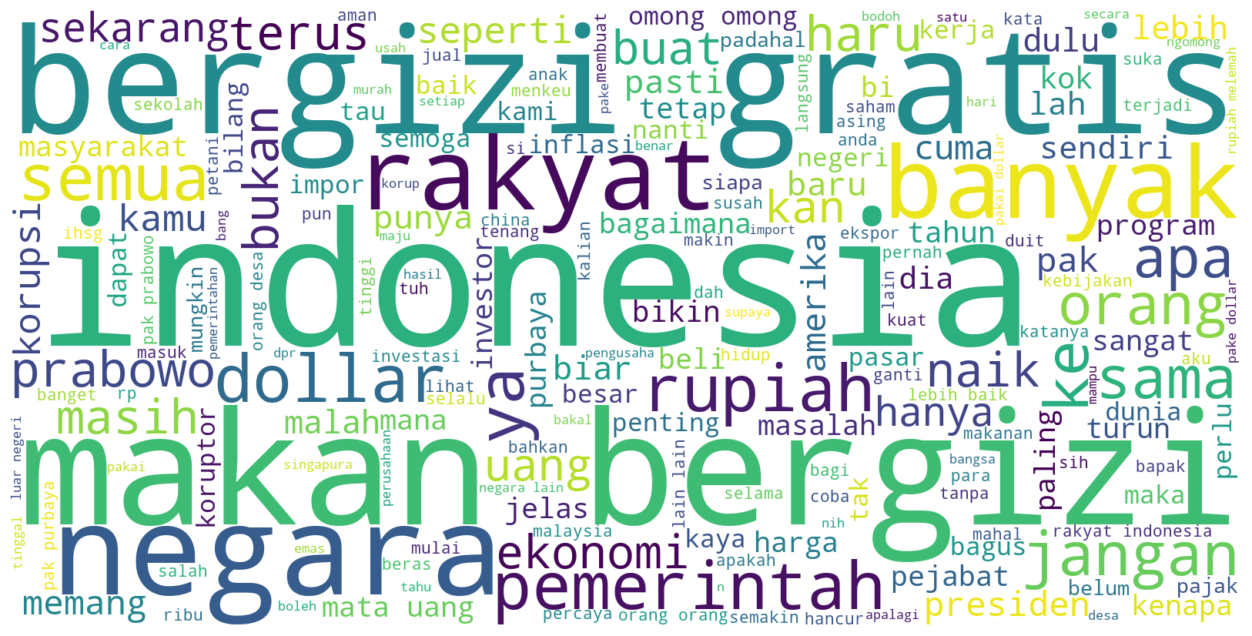

In [31]:
text = " ".join(
    df["processed_text"]
    .dropna()
    .astype(str)
)

from wordcloud import WordCloud, STOPWORDS
stopwords = STOPWORDS.union(custom_stopwords)
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color="white",
    stopwords=stopwords
).generate(text)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


TAHAP 5 - LABELING MANUAL

Agar Kita Dapat Machine Learning, Maka Kita Perlu Membuat Data yang cukup dengan Input dan Output (Label)

In [32]:
sample_df_manual = df[["processed_text"]].sample(
    500,
    random_state=42
)

In [36]:
sample_df_manual["sentiment"] = ""

sample_df_manual.to_csv(
    "labeling_500.csv",
    index=False
)

In [34]:
part_df = df[["processed_text"]].sample(
    3000,
    random_state=42
)

In [35]:
part_df["sentiment"] = ""

part_df.to_csv(
    "labeling_3000.csv",
    index=False
)

NEGATIF = 0
POSITIF = 1
NETRAL = 2

TAHAP 6-MACHINE LEARNING AGAR BISA PREDIKSI OTOMATIS

Setelah Melakukan Labeling Manual Kita Lakukan Proses Pembelajaran Model dengan SVM dan LR

In [37]:
import pandas as pd

df_label = pd.read_csv("labeling_500.csv")

print(df_label["sentiment"].value_counts())

sentiment
0    271
2    141
1     88
Name: count, dtype: int64


encode label

In [38]:
df_label[df_label["sentiment"].isna()]

,processed_text,sentiment


PISAHKAN DATA YANG SUDAH DI LABEL (500 DATA) DENGAN DATA YANG BELOM BERLABEL UNTUK LANJUT PREDIKSI NANTI

In [39]:
part_df = pd.read_csv("labeling_3000.csv")

labeled_texts = set(
    df_label["processed_text"]
)

unlabeled_df = part_df[
    ~part_df["processed_text"]
    .isin(labeled_texts)
]

In [41]:
print(len(part_df))
print(len(df_label))
print(len(unlabeled_df))

3000
500
2500


Gunakan TF-IDF

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

X = vectorizer.fit_transform(df_label["processed_text"])

y = df_label["sentiment"]

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

6.1 Pelatihan Model Support Vector Machine

In [49]:
from sklearn.svm import LinearSVC

model_svm = LinearSVC()

model_svm.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [50]:
y_pred_svm = model_svm.predict(X_test)

Didapatkan classification report dari model SVM dengan Jumlah Data 500

In [51]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=[
            "negatif",
            "positf",
            "netral"
        ]
    )
)

              precision    recall  f1-score   support

     negatif       0.65      0.81      0.72        68
      positf       0.50      0.23      0.31        22
      netral       0.45      0.40      0.42        35

    accuracy                           0.59       125
   macro avg       0.54      0.48      0.49       125
weighted avg       0.57      0.59      0.57       125



In [52]:
from sklearn.metrics import confusion_matrix

cm_svm = confusion_matrix(
    y_test,
    y_pred_svm
)

print(cm_svm)

[[55  4  9]
 [ 9  5  8]
 [20  1 14]]


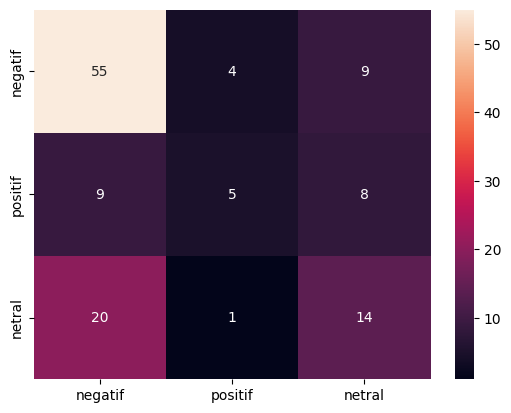

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    xticklabels=["negatif","positif","netral"],
    yticklabels=["negatif","positif","netral"]
)

plt.show()

Dari Model SVM tadi Lanjutkan Prediksi Sentiment Untuk data yang belum berlabel tadi

In [54]:
# transform
X_unlabeled = vectorizer.transform(
    unlabeled_df["processed_text"]
)

# predict
predictions = model_svm.predict(
    X_unlabeled
)

# decode label
reverse_map = {
    0: "negatif",
    1: "positif",
    2: "netral"
}

unlabeled_df["sentiment"] = [
    reverse_map[x]
    for x in predictions
]

In [56]:
print(
    unlabeled_df["sentiment"]
    .value_counts()
)

sentiment
negatif    1673
netral      556
positif     271
Name: count, dtype: int64


In [60]:
unlabeled_df.to_csv(
    "done_labeling_2500_svm.csv",
    index=False
)

In [61]:
df_final = unlabeled_df

Buatkan CloudWord Untuk Masing - Masing Sentiment Di Model SVM

In [62]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

cv = CountVectorizer()

X = cv.fit_transform(df_final["processed_text"])

freq = pd.DataFrame({
    "word": cv.get_feature_names_out(),
    "freq": X.sum(axis=0).A1
})

freq.sort_values("freq", ascending=False).head(50)

,word,freq
8941,yang,1157
8422,tidak,902
1747,dan,803
1871,di,756
3195,indonesia,568
3230,ini,447
7265,saja,383
5665,negara,379
3325,itu,369
285,ada,360


membentuk cloudword di sentiment negative

In [64]:
cv = CountVectorizer()

X = cv.fit_transform(
    df_final[df_final["sentiment"]=="negatif"]["processed_text"]
)

neg_freq = pd.DataFrame({
    "word": cv.get_feature_names_out(),
    "freq": X.sum(axis=0).A1
})

neg_freq.sort_values("freq", ascending=False).head(50)

,word,freq
7073,yang,853
6663,tidak,739
1349,dan,582
1449,di,545
2487,indonesia,381
2515,ini,365
3620,makan,339
4503,negara,326
6285,sudah,313
2590,itu,309


In [66]:
custom_stopwords = {
    "yang",
    "tidak",
    "dan",
    "di",
    "kalau",
    "tapi",
    "nya",
    "lagi",
    "ya",
    "lain",
    "ke",
    "dari",
    "untuk",
    "itu",
    "ini",
    "ada",
    "sudah",
    "akan",
    "saja",
    "masih",
    "jadi",
    "lebih",
    "karena",
    "dengan",
    "dalam",
    "bahwa",
    "agar"
}

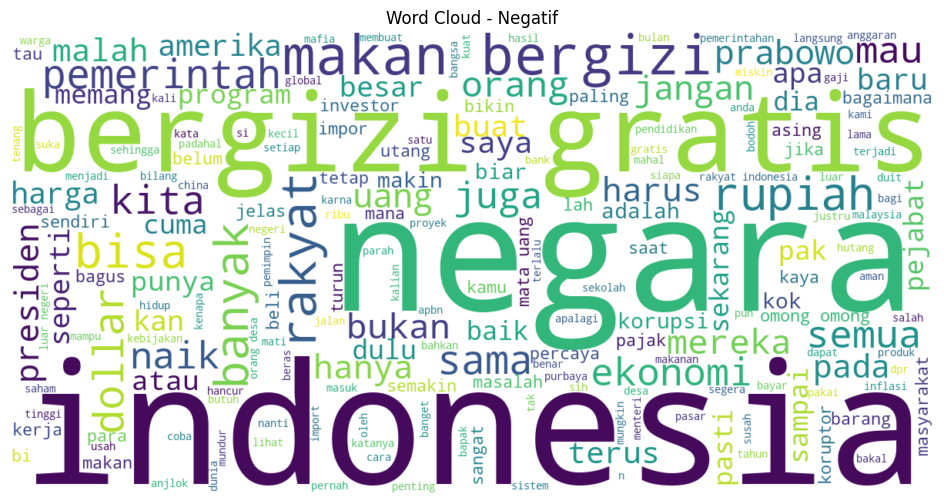

In [69]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

negatif_text = " ".join(
    df_final[df_final["sentiment"] == "negatif"]["processed_text"]
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=custom_stopwords,
).generate(negatif_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Negatif")
plt.show()

CLOUDWORD POSITIF

In [70]:
cv = CountVectorizer()

X = cv.fit_transform(
    df_final[df_final["sentiment"]=="positif"]["processed_text"]
)

pos_freq = pd.DataFrame({
    "word": cv.get_feature_names_out(),
    "freq": X.sum(axis=0).A1
})

pos_freq.sort_values("freq", ascending=False).head(50)

,word,freq
425,dan,148
700,indonesia,138
2040,yang,120
456,di,117
911,kita,79
1357,pak,56
1934,tidak,51
1710,semoga,48
1999,untuk,44
1279,negara,44


In [72]:
custom_stopwords_pos = {
    "dan",
    "yang",
    "di",
    "kita",
    "tidak",
    "ini",
    "dengan",
    "ke",
    "dalam",
    "jangan",
    "ada",
    "saja",
    "kalau",
    "akan",
    "itu",
    "dari",
    "sampai"
}

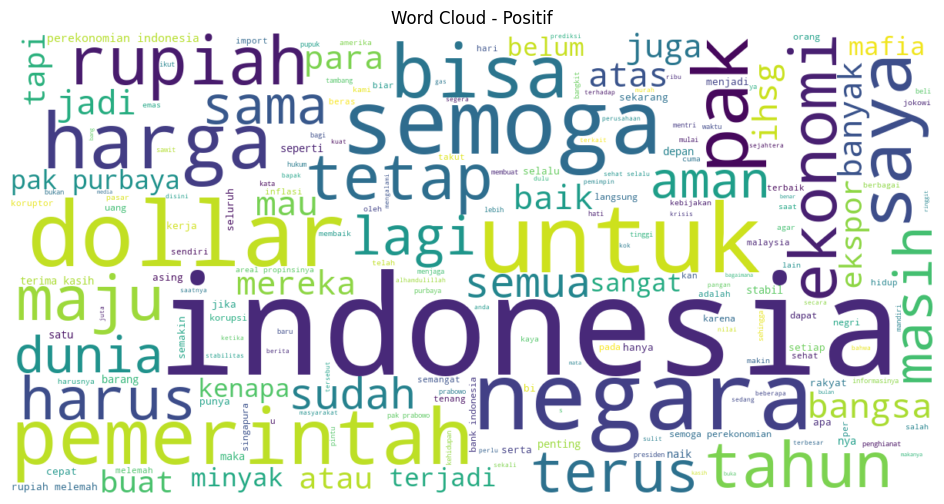

In [73]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positif_text = " ".join(
    df_final[df_final["sentiment"] == "positif"]["processed_text"]
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=custom_stopwords_pos,
).generate(positif_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Positif")
plt.show()

In [74]:
cv = CountVectorizer()

X = cv.fit_transform(
    df_final[df_final["sentiment"]=="netral"]["processed_text"]
)

netral_freq = pd.DataFrame({
    "word": cv.get_feature_names_out(),
    "freq": X.sum(axis=0).A1
})

netral_freq.sort_values("freq", ascending=False).head(50)

,word,freq
2917,yang,184
2736,tidak,112
660,di,94
172,apa,89
85,ada,83
2354,saja,73
606,dan,73
426,bisa,72
2907,ya,68
1137,jadi,64


In [75]:
custom_stopwords_netral = {
    "dan",
    "yang",
    "di",
    "kita",
    "tidak",
    "ini",
    "dengan",
    "ke",
    "dalam",
    "jangan",
    "ada",
    "saja",
    "kalau",
    "akan",
    "itu",
    "dari",
    "sampai",
    "yang",
    "tidak",
    "dan",
    "di",
    "kalau",
    "tapi",
    "nya",
    "lagi",
    "ya",
    "lain",
    "ke",
    "dari",
    "untuk",
    "itu",
    "ini",
    "ada",
    "sudah",
    "akan",
    "saja",
    "masih",
    "jadi",
    "lebih",
    "karena",
    "dengan",
    "dalam",
    "bahwa",
    "agar"
}

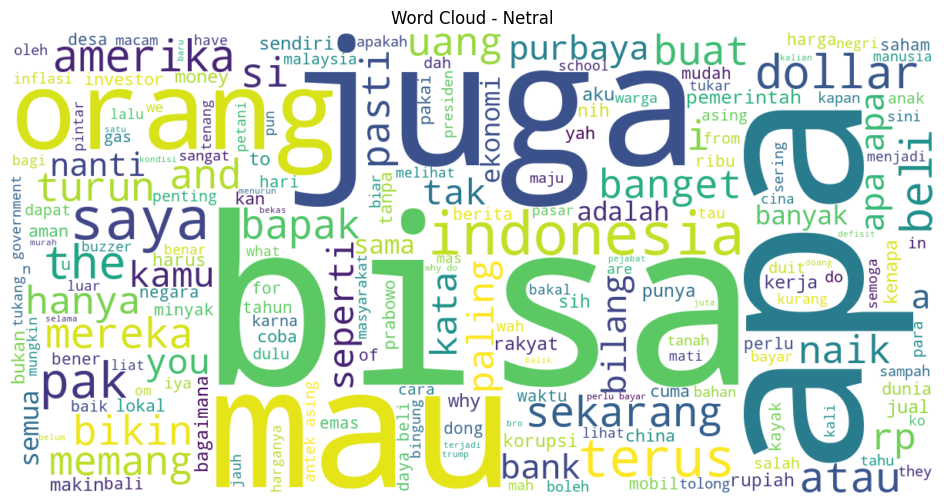

In [76]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

netral_text = " ".join(
    df_final[df_final["sentiment"] == "netral"]["processed_text"]
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=custom_stopwords_netral,
).generate(netral_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Netral")
plt.show()

6.2 Lakukan Pelatihan dengan Menggunakan Model LogisticRegression

In [77]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42
)

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)


classification report dari Model Logistic Regression dengan Jumlah Data 500

In [78]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=[
            "negatif",
            "positf",
            "netral"
        ]
    )
)

              precision    recall  f1-score   support

     negatif       0.69      0.63      0.66        68
      positf       0.33      0.32      0.33        22
      netral       0.45      0.54      0.49        35

    accuracy                           0.55       125
   macro avg       0.49      0.50      0.49       125
weighted avg       0.56      0.55      0.56       125



In [79]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

print(cm_lr)

[[43 11 14]
 [ 6  7  9]
 [13  3 19]]


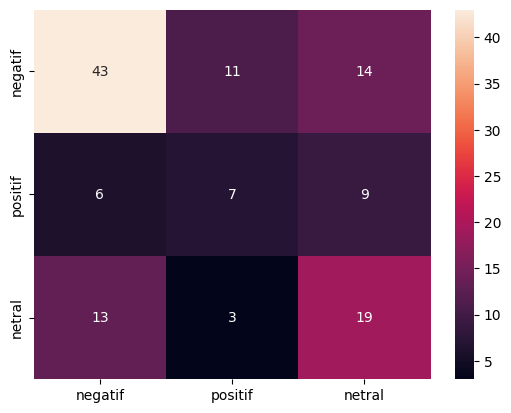

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    xticklabels=["negatif","positif","netral"],
    yticklabels=["negatif","positif","netral"]
)

plt.show()

dengan Model LR lakukan prediksi dengan data yang belum diberi label tadi

In [81]:
# transform
X_unlabeled = vectorizer.transform(
    unlabeled_df["processed_text"]
)

# predict
predictions = model_lr.predict(
    X_unlabeled
)

# decode label
reverse_map = {
    0: "negatif",
    1: "positif",
    2: "netral"
}

unlabeled_df["sentiment"] = [
    reverse_map[x]
    for x in predictions
]

In [82]:
print(
    unlabeled_df["sentiment"]
    .value_counts()
)

sentiment
negatif    1249
netral      769
positif     482
Name: count, dtype: int64


In [83]:
unlabeled_df.to_csv(
    "done_labeling_2500_lr.csv",
    index=False
)

In [84]:
df_final_lr = unlabeled_df

Buatkan CloudWord Untuk Masing - Masing Sentiment Di Model LR

In [85]:
cv = CountVectorizer()

X = cv.fit_transform(
    df_final_lr[df_final_lr["sentiment"]=="negatif"]["processed_text"]
)

neg_freq = pd.DataFrame({
    "word": cv.get_feature_names_out(),
    "freq": X.sum(axis=0).A1
})

neg_freq.sort_values("freq", ascending=False).head(50)

,word,freq
5871,yang,666
5523,tidak,624
1108,dan,422
1191,di,399
2997,makan,334
1848,gratis,293
643,bergizi,267
2072,ini,262
5211,sudah,253
2131,itu,251


In [ ]:
custom_stopwords_lr = {
    "dan",
    "yang",
    "di",
    "kita",
    "tidak",
    "ini",
    "dengan",
    "ke",
    "dalam",
    "jangan",
    "ada",
    "saja",
    "kalau",
    "akan",
    "itu",
    "dari",
    "sampai",
    "yang",
    "tidak",
    "dan",
    "di",
    "kalau",
    "tapi",
    "nya",
    "lagi",
    "ya",
    "lain",
    "ke",
    "dari",
    "untuk",
    "itu",
    "ini",
    "ada",
    "sudah",
    "akan",
    "saja",
    "masih",
    "jadi",
    "lebih",
    "karena",
    "dengan",
    "dalam",
    "bahwa",
    "agar"
}

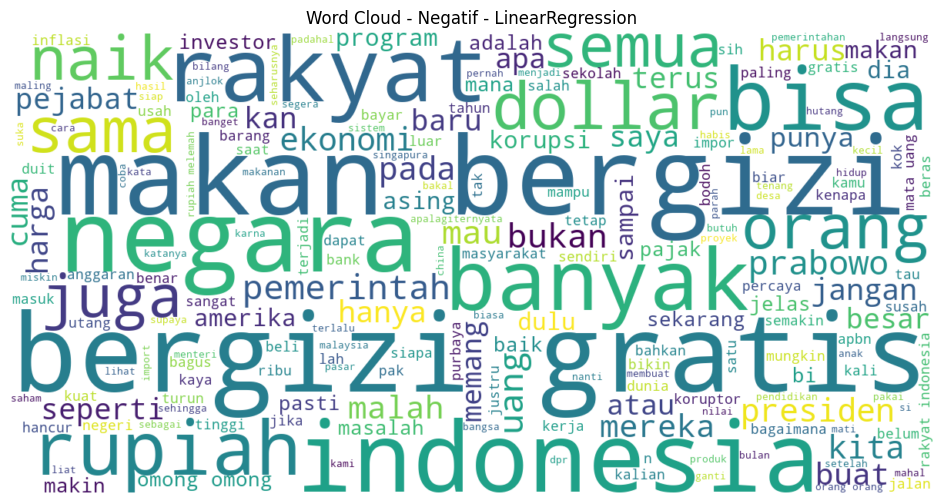

In [86]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

negatif_text = " ".join(
    df_final_lr[df_final_lr["sentiment"] == "negatif"]["processed_text"]
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=custom_stopwords,
).generate(negatif_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Negatif - LinearRegression")
plt.show()

In [87]:
cv = CountVectorizer()

X = cv.fit_transform(
    df_final_lr[df_final_lr["sentiment"]=="positif"]["processed_text"]
)

pos_freq = pd.DataFrame({
    "word": cv.get_feature_names_out(),
    "freq": X.sum(axis=0).A1
})

pos_freq.sort_values("freq", ascending=False).head(50)

,word,freq
694,dan,314
1185,indonesia,278
3445,yang,276
745,di,248
3260,tidak,134
2170,negara,127
1536,kita,123
1202,ini,121
2311,pak,106
726,dengan,99


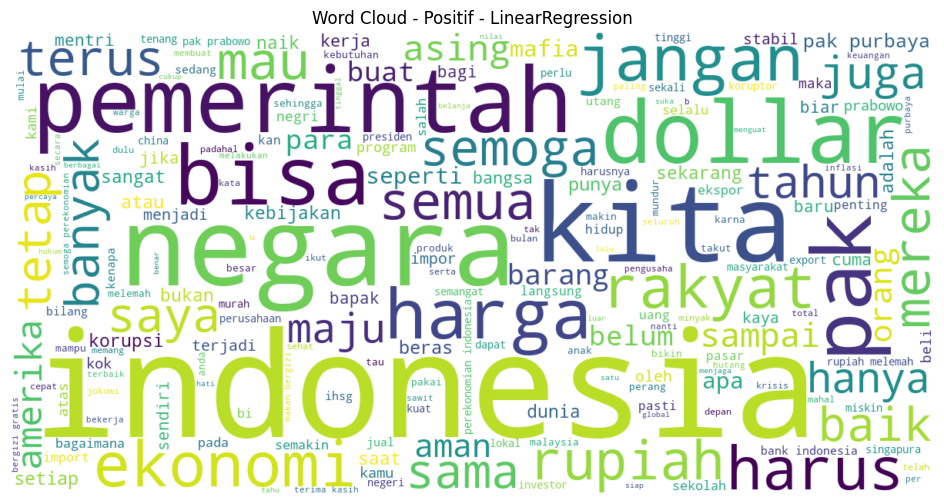

In [88]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positif_text = " ".join(
    df_final_lr[df_final_lr["sentiment"] == "positif"]["processed_text"]
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=custom_stopwords,
).generate(positif_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Positif - LinearRegression")
plt.show()